### Questao 1.1: Quantas instâncias e quantos atributos existem?

In [1]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')
display(df.shape)

(119390, 32)

### Questao 1.2: Quais atributos são numéricos e quais são categóricos?

In [2]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')
display(df.dtypes)


def verifyAtribute(df):
    countC = 0
    countN = 0

    for column in df.columns:
        if df[column].dtype != 'str' and df[column].nunique() != 2:
            countN += 1
        else:
            countC += 1

    return countC, countN

categoricos, numericos = verifyAtribute(df)

print("Categóricos:", categoricos)
print("Numéricos:", numericos)



hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

Categóricos: 14
Numéricos: 18


### Questao 1.3: Quais atributos são binários?

In [14]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')

def verifyBi(df):
    result = []

    for column in df.columns:
        if df[column].nunique() == 2:
            result.append({
                'Attribute': column,
                'Values': df[column].dropna().unique()
            })

    return result

display(pd.DataFrame(verifyBi(df)))

,Attribute,Values
0,hotel,"[Resort Hotel, City Hotel]"
1,is_canceled,"[0, 1]"
2,is_repeated_guest,"[0, 1]"


### Questao 1.4: Quais atributos representam características da reserva, do cliente, da estadia e do hotel?

In [4]:
##Pulei por enquanto


### Questao 2.5: Existem valores faltantes? Em quais atributos e em que quantidade? 

In [15]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')

def valueOff(df):
    result = []

    for column in df.columns:
        null_count = df[column].isnull().sum()

        if null_count != 0:
            result.append({
                'Attribute': column,
                'Null Values': null_count
            })

    return result


display(pd.DataFrame(valueOff(df)))

,Attribute,Null Values
0,children,4
1,country,488
2,agent,16340
3,company,112593


### Questao 2.6: Existem registros duplicados? 

In [19]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')
df.duplicated().sum()

np.int64(31994)

### Questao 2.7: Quais atributos possuem grande quantidade de valores distintos?

In [12]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')

def verifyDistinct(df):
    result = []
    for column in df.columns:
        if df[column].nunique() >= 100:
            result.append({'atrubute': column, 'distinc values': df[column].nunique()}) 
    return result

display(pd.DataFrame(verifyDistinct(df)))


,atrubute,distinc values
0,lead_time,479
1,country,177
2,agent,333
3,company,352
4,days_in_waiting_list,128
5,adr,8879
6,reservation_status_date,926


### Questao 2.8: Quais problemas de qualidade precisam ser considerados antes de uma análise posterior?
Resposta: Entre esses casos, acredito que devam ser tartados: 
- Valores Nulos(NaN), podem vir a prejudicar a analise desses dados. 
- Valores com linhas duplicadas, podem vir a distorcer as analises.
- Os atributos com valores extremos que podem significar a presenca de outliers.

### Questao 3: Calcule média, mediana, mínimo, máximo, quartis, amplitude, IQR e desvio padrão para os principais atributos numéricos.
Nesse arquivo eu vou fazer duas funcoes, uma pra pegar exatamente as colunas especificas apresentadas e outra para usar em qualquer csv generica, pegando e calculando para todas as colunas


In [8]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')
df.describe()

#Funcao Especifica
def func1(df):
    attributes = [
        'lead_time',
        'stays_in_weekend_nights',
        'stays_in_week_nights',
        'adults',
        'children',
        'babies',
        'previous_cancellations',
        'booking_changes',
        'days_in_waiting_list',
        'adr',
        'total_of_special_requests'
    ]
    stats = df[attributes].describe()
    stats.loc['amplitude'] = stats.loc['max'] - stats.loc['min']
    stats.loc['IQR'] = stats.loc['75%'] - stats.loc['25%']
    return stats

display(func1(df))

#Funcao generica
# def func2(df):
#     stats = df.describe()
#     stats.loc['amplitude'] = stats.loc['max'] - stats.loc['min']
#     stats.loc['IQR'] = stats.loc['75%'] - stats.loc['25%']
#     return stats

# display(func2(df))

    

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,booking_changes,days_in_waiting_list,adr,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,104.011416,0.927599,2.500302,1.856403,0.103890,0.007949,0.087118,0.221124,2.321149,101.831122,0.571363
std,106.863097,0.998613,1.908286,0.579261,0.398561,0.097436,0.844336,0.652306,17.594721,50.535790,0.792798
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000
25%,18.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.290000,0.000000
50%,69.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.575000,0.000000
75%,160.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,1.000000
max,737.000000,19.000000,50.000000,55.000000,10.000000,10.000000,26.000000,21.000000,391.000000,5400.000000,5.000000
amplitude,737.000000,19.000000,50.000000,55.000000,10.000000,10.000000,26.000000,21.000000,391.000000,5406.380000,5.000000
IQR,142.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.710000,1.000000


### Gráfico 1 – Distribuição do tempo de antecedência das reservas

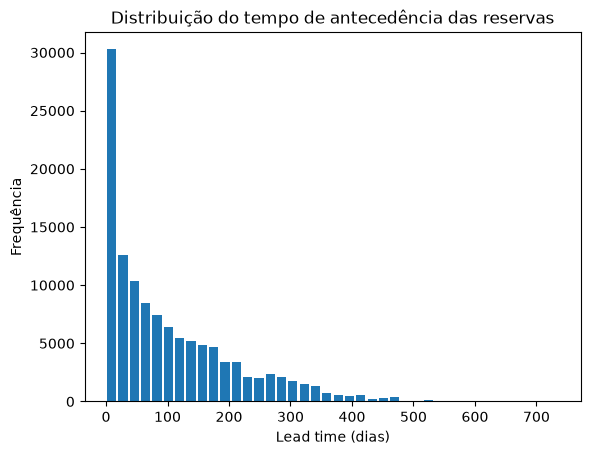

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

%matplotlib inline

df['lead_time'].plot.hist(
    bins=40,
    rwidth=0.8
)

plt.title('Distribuição do tempo de antecedência das reservas')
plt.xlabel('Lead time (dias)')
plt.ylabel('Frequência')

plt.show()

### Gráfico 2 – Distribuição do preço médio diário (ADR)

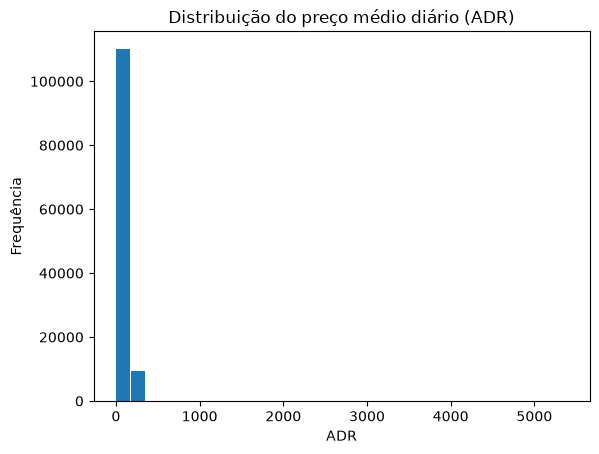

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

48515     5400.00
111403     510.00
15083      508.00
103912     451.50
13142      450.00
13391      437.00
39155      426.25
39568      402.00
39118      397.38
13323      392.00
39517      392.00
39543      388.00
13406      388.00
39177      387.00
9728       384.00
39960      383.00
9768       382.00
39644      382.00
38995      378.00
13480      378.00
Name: adr, dtype: float64

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

df['adr'].plot.hist(
    bins=30,
    rwidth=0.9
)

plt.title('Distribuição do preço médio diário (ADR)')
plt.xlabel('ADR')
plt.ylabel('Frequência')

plt.show()

# isso aqui foi so pra conferir, nao eh necessario nao
display(df['adr'].describe())
display(df['adr'].sort_values(ascending=False).head(20))

### Gráfico 3 – Boxplot do ADR por tipo de hotel